In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Preprocessing

In [2]:
df = pd.read_csv("../data/updated_data.csv")

df["ecec_diffusion"] = df["ecec_diffusion"].fillna(df["ecec_diffusion"].median())

In [3]:
ecec_covariates = ["ecec_participation", "coverage", "public_coverage", "private_coverage", "per_capita_public_expenditure", 
                   "per_capita_user_contribution", "other_percapita_public_expenditure", "other_percapita_user_contrib",
                   "other_per_capita_expenditure", "ecec_diffusion"]
    
categorical_cols = ["prov_name", "urban_type"]

empl_variables = ["empl_rate", "inact_rate", "empl_gap", "part_rate", "unempl_rate", "wr_men"]

target = "fem_empl_rate"
offset = "wr_men"

In [4]:
to_drop = ecec_covariates + categorical_cols + empl_variables + [target]
df_variables = df.drop(columns=to_drop)

n_obs, n_feat = df_variables.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Number of observations: 107, number of predictors: 32


## Correlation Based Selection

In [5]:
corr_matrix = df_variables.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.89

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [6]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
              var1                   var2   corr
net_migration_rate adj_net_migration_rate  0.985
      fem_edu_rate          male_edu_rate  0.952


In [7]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(net_migration_rate, 1)
(fem_edu_rate, 1)
(adj_net_migration_rate, 1)
(male_edu_rate, 1)


In [8]:
to_drop = ["adj_net_migration_rate", "male_edu_rate"]

df_reduced = df_variables.drop(columns=to_drop)

## Bayesian Lasso

In [9]:
selected_covariates = list(df_reduced.columns)

X = df[selected_covariates].to_numpy()
offset = df[offset].to_numpy()
y = df[target].to_numpy()

X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

y = y / 100
y_star = np.log(y / (1 - y))

offset = offset / 100
logit_offset = np.log(offset / (1 - offset))

n_obs, n_feat = X_star.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 30


In [10]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_star)
    y_data = pm.Data("y_data", y_star)
    offset = pm.Data("offset", logit_offset)

    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0) 
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
    
    mu = pm.math.dot(X_data, beta) + intercept + offset

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_sq, sigma, beta, alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.


In [11]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

selected_covariates_df = summary_beta_95[~summary_beta_95["contains_zero"]].index.tolist()

                           mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate           -0.323    -0.405     -0.243          False
net_migration_rate       -0.104    -0.169     -0.028          False
n_members_family         -0.084    -0.143     -0.030          False
ageing_index              0.073    -0.018      0.174           True
avg_children_per_woman   -0.065    -0.123      0.000           True
fertility_rate           -0.055    -0.144      0.020           True
fem_maj_empl_rate         0.041     0.009      0.072          False
dependency_rate          -0.035    -0.107      0.019           True
fem_edu_rate             -0.027    -0.064      0.011           True
advanced_business_empl   -0.023    -0.085      0.036           True
eco_urban_index           0.021    -0.009      0.052           True
first_birth_maternal_age  0.018    -0.020      0.062           True
service_empl_rate         0.018    -0.013      0.053           True
n_large_comp             -0.017    -0.061      0

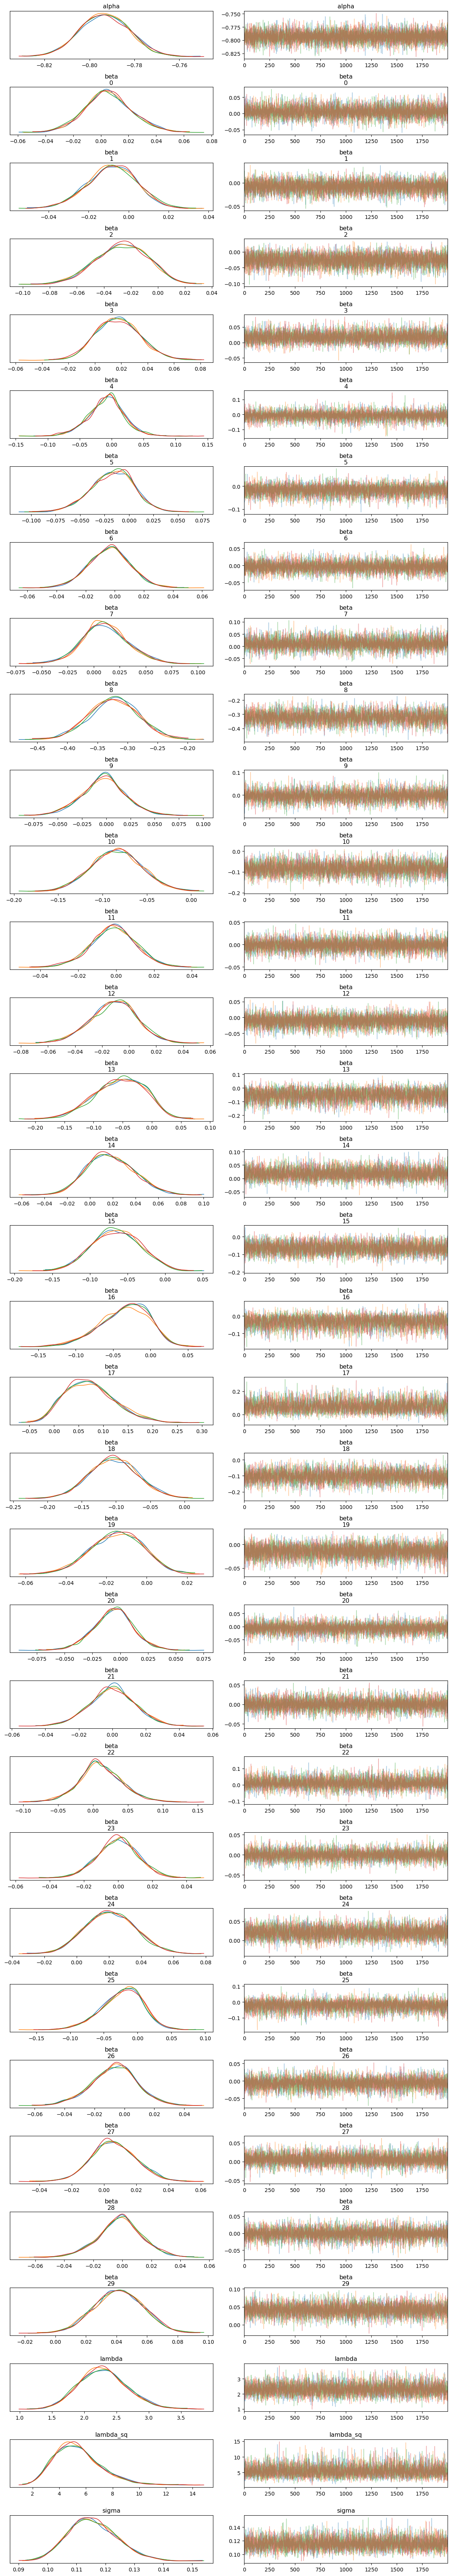

In [12]:
az.rcParams["plot.max_subplots"] = 100   
az.plot_trace(trace, compact=False)
plt.tight_layout()

# az.plot_trace(trace)
# plt.tight_layout()

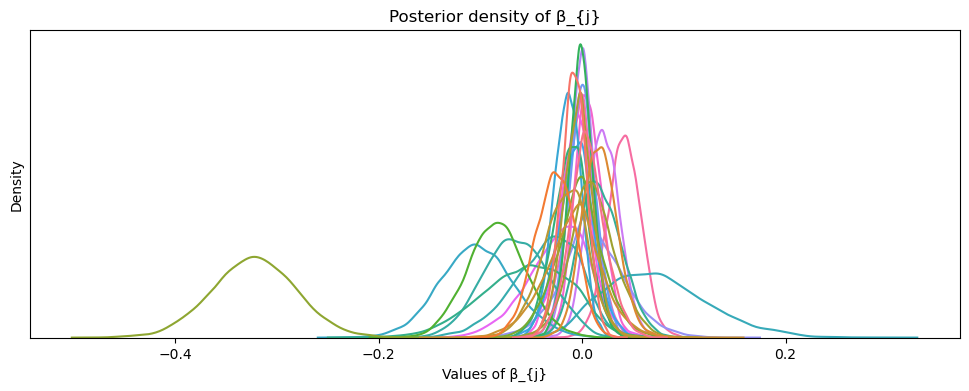

In [13]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)

plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()

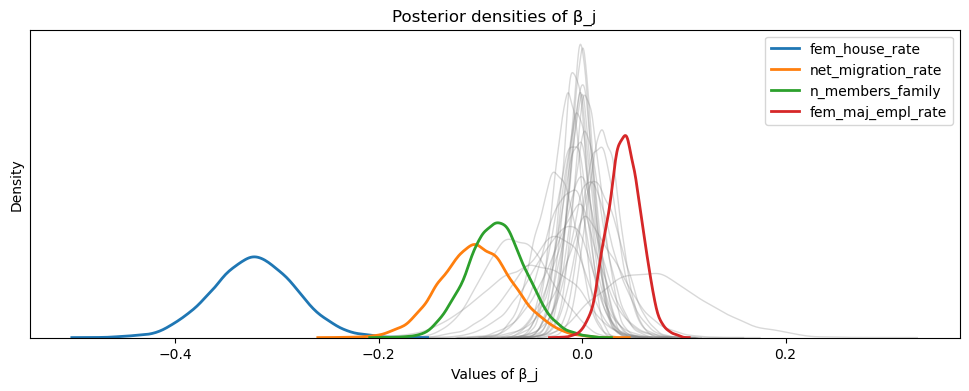

In [14]:
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  
if beta_raw.shape[0] == len(selected_covariates):
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

## ECEC Covariates Correlation

In [15]:
df_ecec = df[ecec_covariates]
df_ecec = df_ecec.drop(columns=["private_coverage"])

In [16]:
corr_matrix = df[ecec_covariates].corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.89

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [17]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                         var2   corr
other_percapita_public_expenditure other_per_capita_expenditure  0.995


In [18]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(other_percapita_public_expenditure, 1)
(other_per_capita_expenditure, 1)


In [19]:
ecec_to_drop = ["other_per_capita_expenditure"]

df_ecec = df_ecec.drop(columns=ecec_to_drop)

ecec_selected = list(df_ecec.columns)

## Results

In [20]:
final_covariates = selected_covariates_df + ecec_selected
print(f"{len(final_covariates)} selected covariates:")
print(final_covariates)

12 selected covariates:
['fem_house_rate', 'net_migration_rate', 'n_members_family', 'fem_maj_empl_rate', 'ecec_participation', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'per_capita_user_contribution', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']


In [21]:
freq_lasso_selection = ["coverage", "per_capita_public_expenditure", "ageing_index", "ecec_participation", "per_capita_user_contribution", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]

In [22]:
all_covariates = sorted(set(final_covariates) | set(freq_lasso_selection))

# Build and print the table
print(f"{'covariate':40s} | {'in_final_covariates':20s} | {'in_freq_lasso':15s}")
print("-" * 85)

for cov in all_covariates:
    in_final = cov in final_covariates
    in_freq  = cov in freq_lasso_selection
    print(f"{cov:40s} | {str(in_final):20s} | {str(in_freq):15s}")

covariate                                | in_final_covariates  | in_freq_lasso  
-------------------------------------------------------------------------------------
ageing_index                             | False                | True           
avg_children_per_woman                   | False                | True           
coverage                                 | True                 | True           
ecec_diffusion                           | True                 | True           
ecec_participation                       | True                 | True           
fem_house_rate                           | True                 | True           
fem_maj_empl_rate                        | True                 | False          
n_members_family                         | True                 | True           
net_migration_rate                       | True                 | False          
other_percapita_public_expenditure       | True                 | False          
other_percap